sample data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import zscore


data = {
    "Employee": [
        "A", "B", "C", "D", "E",
        "F", "G", "H", "I", "J"
    ],

    "Experience": [
        1, 2, 2, 3, 4,
        5, 6, 7, 8, 1
    ],

    "Salary": [
        20000, 22000, 25000, 27000, 30000,
        35000, 40000, 45000, 50000, 500000
    ]
}
df = pd.DataFrame(data)

print(df)

  Employee  Experience  Salary
0        A           1   20000
1        B           2   22000
2        C           2   25000
3        D           3   27000
4        E           4   30000
5        F           5   35000
6        G           6   40000
7        H           7   45000
8        I           8   50000
9        J           1  500000


outlier

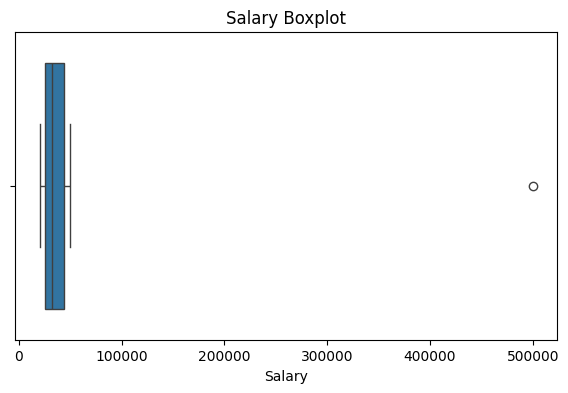


 IQR 
Q1: 25500.0
Q3: 43750.0
IQR: 18250.0

 BOUNDS 
Lower Bound: -1875.0
Upper Bound: 71125.0

 OUTLIERS (IQR METHOD) 
  Employee  Experience  Salary
9        J           1  500000


In [3]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df["Salary"]
)

plt.title("Salary Boxplot")

plt.show()

Q1 = df["Salary"].quantile(0.25)

Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

print("\n IQR ")

print("Q1:", Q1)

print("Q3:", Q3)

print("IQR:", IQR)

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

print("\n BOUNDS ")

print("Lower Bound:", lower)

print("Upper Bound:", upper)

outliers_iqr = df[
    (df["Salary"] < lower) |
    (df["Salary"] > upper)
]

print("\n OUTLIERS (IQR METHOD) ")

print(outliers_iqr)

 Remove Outliers

In [5]:
df_removed = df[
    (df["Salary"] >= lower) &
    (df["Salary"] <= upper)
]

print("\n DATA AFTER REMOVING OUTLIERS ")
print(df_removed)



 DATA AFTER REMOVING OUTLIERS 
  Employee  Experience  Salary
0        A           1   20000
1        B           2   22000
2        C           2   25000
3        D           3   27000
4        E           4   30000
5        F           5   35000
6        G           6   40000
7        H           7   45000
8        I           8   50000


Compare Distribution

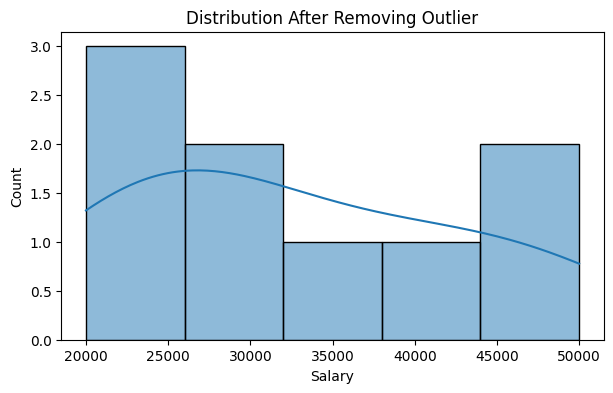

In [7]:
plt.figure(figsize=(7,4))

sns.histplot(
    df_removed["Salary"],
    kde=True
)

plt.title("Distribution After Removing Outlier")
plt.show()


 Z-Score Method

In [9]:
df["zscore"] = zscore(df["Salary"])

print("\n Z-SCORE ")

print(df[["Employee", "Salary", "zscore"]])


 Z-SCORE 
  Employee  Salary    zscore
0        A   20000 -0.422731
1        B   22000 -0.408498
2        C   25000 -0.387148
3        D   27000 -0.372914
4        E   30000 -0.351564
5        F   35000 -0.315981
6        G   40000 -0.280397
7        H   45000 -0.244814
8        I   50000 -0.209230
9        J  500000  2.993277


Detect Outliers using Z-score

In [10]:
z_outliers = df[
    df["zscore"].abs() > 3
]

print("\n OUTLIERS (Z-SCORE METHOD)")

print(z_outliers)


 OUTLIERS (Z-SCORE METHOD)
Empty DataFrame
Columns: [Employee, Experience, Salary, zscore]
Index: []


Scatterplot for Relationship Outlier

Text(0.5, 1.0, 'Experience vs Salary')

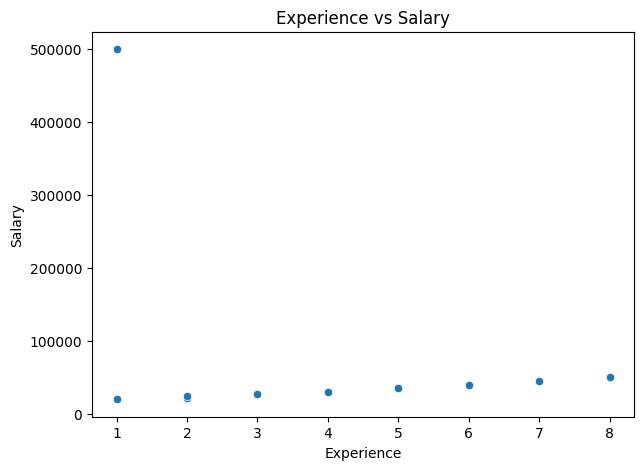

In [11]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    x=df["Experience"],
    y=df["Salary"]
)

plt.title("Experience vs Salary")


Winsorization / Capping

In [12]:
df_cap = df.copy()

df_cap["Salary"] = df_cap["Salary"].clip(
    lower,
    upper
)

print("\n AFTER CAPPING ")

print(df_cap)


 AFTER CAPPING 
  Employee  Experience  Salary    zscore
0        A           1   20000 -0.422731
1        B           2   22000 -0.408498
2        C           2   25000 -0.387148
3        D           3   27000 -0.372914
4        E           4   30000 -0.351564
5        F           5   35000 -0.315981
6        G           6   40000 -0.280397
7        H           7   45000 -0.244814
8        I           8   50000 -0.209230
9        J           1   71125  2.993277


Boxplot After Capping

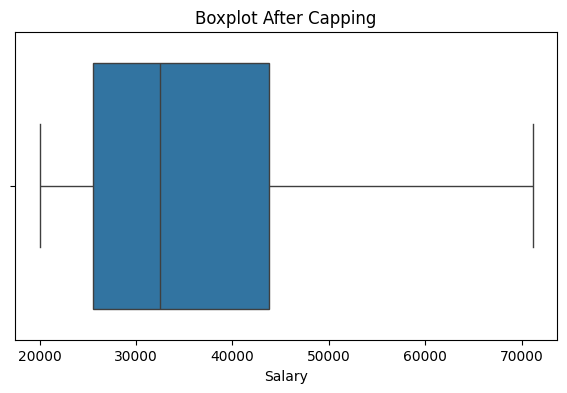

In [13]:
plt.figure(figsize=(7,4))

sns.boxplot(
    x=df_cap["Salary"]
)

plt.title("Boxplot After Capping")

plt.show()

 Log Transformation

In [14]:
df_log = df.copy()

df_log["Salary"] = np.log(df_log["Salary"])

print("\n LOG TRANSFORMED DATA ")

print(df_log[["Employee", "Salary"]])


 LOG TRANSFORMED DATA 
  Employee     Salary
0        A   9.903488
1        B   9.998798
2        C  10.126631
3        D  10.203592
4        E  10.308953
5        F  10.463103
6        G  10.596635
7        H  10.714418
8        I  10.819778
9        J  13.122363


Distribution After Log Transform

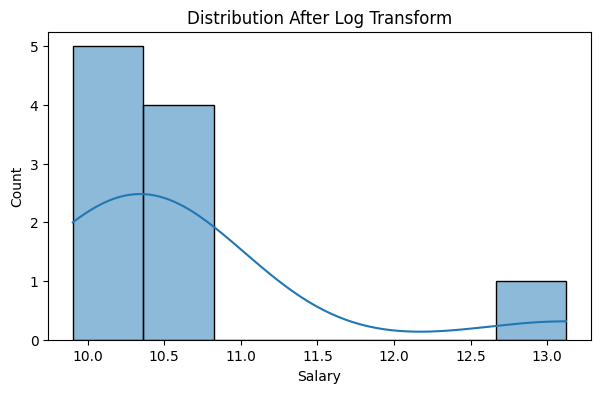

In [15]:
plt.figure(figsize=(7,4))

sns.histplot(
    df_log["Salary"],
    kde=True
)

plt.title("Distribution After Log Transform")

plt.show()